In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
import os

os.listdir("/kaggle/input/addvertising-sales-predict")


['advertising.csv']

In [4]:
import pandas as pd

df = pd.read_csv("/kaggle/input/addvertising-sales-predict/advertising.csv")


In [5]:
df.head()


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [7]:
df['Sales'].describe()


count    200.000000
mean      15.130500
std        5.283892
min        1.600000
25%       11.000000
50%       16.000000
75%       19.050000
max       27.000000
Name: Sales, dtype: float64

In [9]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']



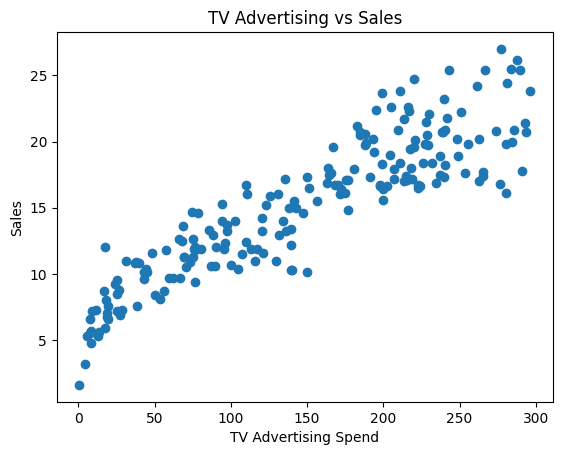

In [10]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df['TV'], df['Sales'])
plt.xlabel('TV Advertising Spend')
plt.ylabel('Sales')
plt.title('TV Advertising vs Sales')
plt.show()


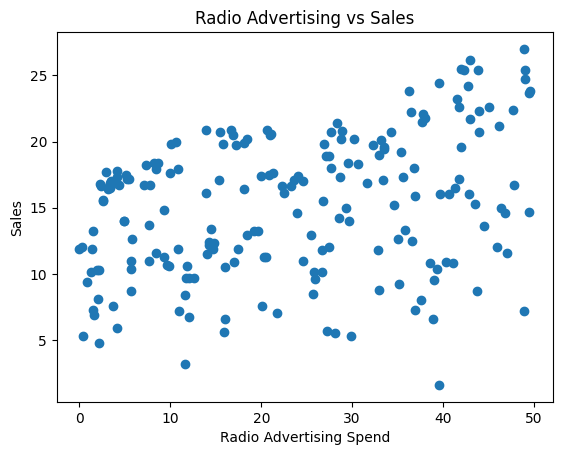

In [16]:
plt.figure()
plt.scatter(df['Radio'], df['Sales'])
plt.xlabel('Radio Advertising Spend')
plt.ylabel('Sales')
plt.title('Radio Advertising vs Sales')
plt.show()


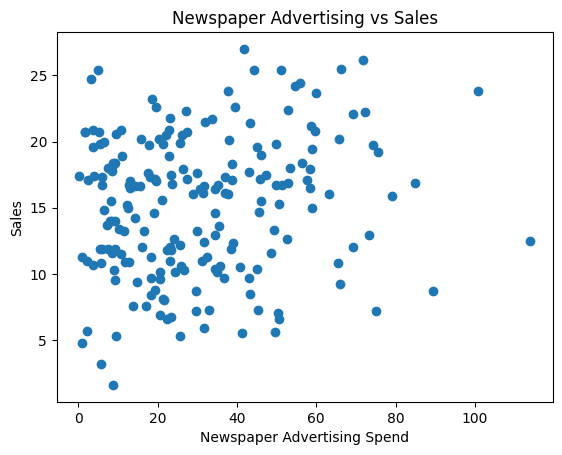

In [17]:
plt.figure()
plt.scatter(df['Newspaper'], df['Sales'])
plt.xlabel('Newspaper Advertising Spend')
plt.ylabel('Sales')
plt.title('Newspaper Advertising vs Sales')
plt.show()


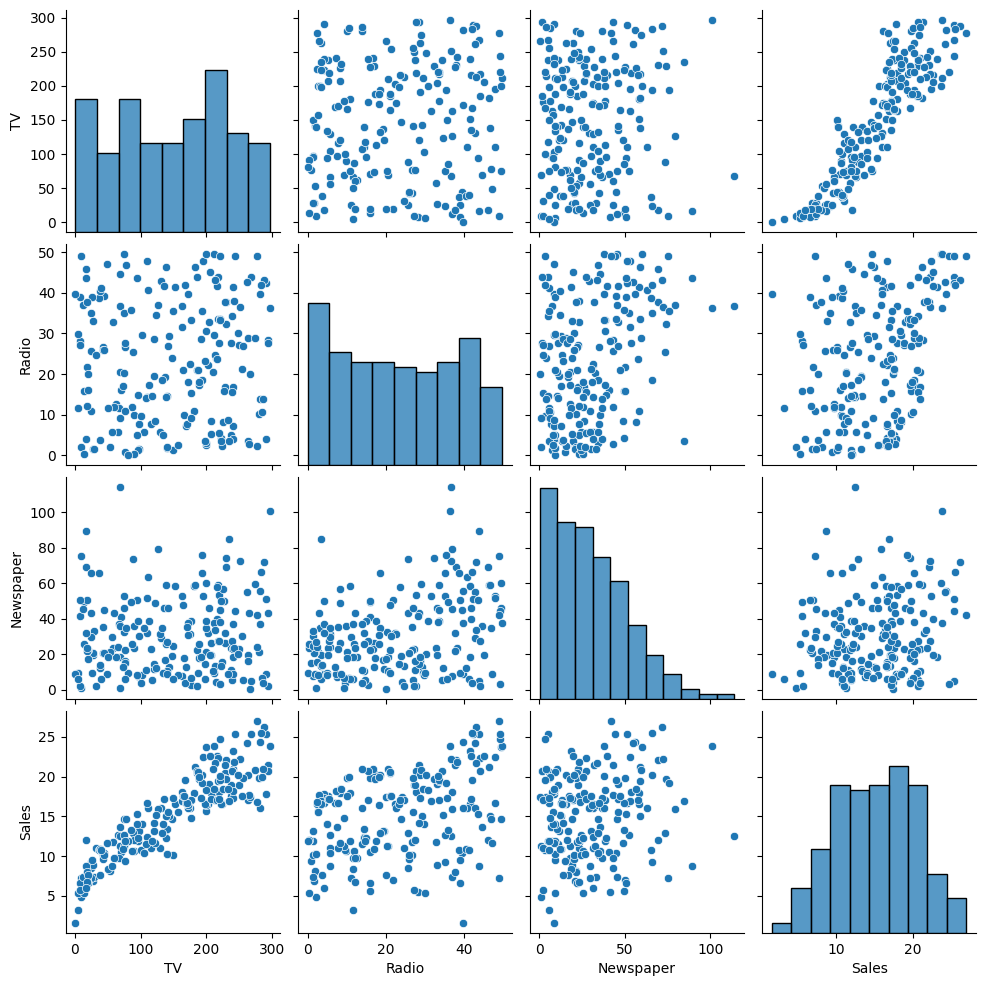

In [18]:
import seaborn as sns

sns.pairplot(df)
plt.show()


In [21]:
df.dtypes


TV            float64
Radio         float64
Newspaper     float64
Sales         float64
Radio_bin    category
dtype: object

In [22]:
df_numeric = df.select_dtypes(include='number')
df_numeric.corr()


,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.901208
Radio,0.054809,1.000000,0.354104,0.349631
Newspaper,0.056648,0.354104,1.000000,0.157960
Sales,0.901208,0.349631,0.157960,1.000000


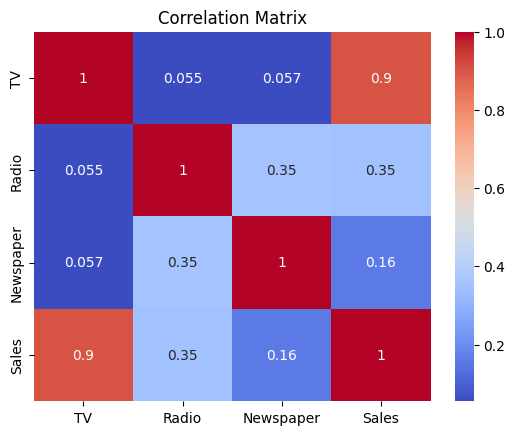

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


In [27]:
from sklearn.model_selection import train_test_split

X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [28]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [29]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2, rmse


(0.9059011844150826, np.float64(1.7052146229349223))

In [30]:
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coeff_df


,Feature,Coefficient
0,TV,0.054509
1,Radio,0.100945
2,Newspaper,0.004337


**# Final Conclusion**
In this project, sales prediction was performed using advertising expenditure data for TV, radio, and newspaper platforms. Exploratory Data Analysis revealed that TV advertising has a strong positive relationship with sales, radio advertising has a moderate impact, and newspaper advertising shows minimal influence.

A Linear Regression model was built and evaluated using R² score and RMSE. The model achieved an R² score of approximately 0.91, indicating that it explains about 90% of the variation in sales, with an average prediction error of around 1.7 units.

Coefficient analysis showed that radio advertising has the highest per-unit impact on sales, while TV advertising remains the most influential overall predictor due to its strong correlation and wider spending range. Newspaper advertising contributes very little to sales prediction.

Overall, the results confirm that TV and radio advertising are key drivers of sales, and Linear Regression is an effective model for this prediction task.